<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/open_close.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pmdarima
!pip install odfpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Load the data
try:
    df = pd.read_excel('Hindustan_copper.ods', engine='odf') # Corrected filename
except FileNotFoundError:
    print("Error: 'Hindustan_copper.ods' not found. Please upload the file.")
    raise

# Parse datetime, set as index, sort, and assign business day frequency
df['datetime'] = pd.to_datetime(df['datetime']) # Corrected 'Datetime' to 'datetime'
df = df.set_index('datetime') # Corrected 'Datetime' to 'datetime'
df = df.sort_index()
df = df.asfreq('B', method='ffill')

print("Data loaded and preprocessed:")
display(df.head())

Data loaded and preprocessed:


,symbol,open,high,low,close,volume
datetime,,,,,,
2016-01-04 00:00:00+05:30,HINDALCO,84.20,85.90,80.4,80.75,8706224
2016-01-05 00:00:00+05:30,HINDALCO,82.00,83.95,80.6,82.60,9819068
2016-01-06 00:00:00+05:30,HINDALCO,82.40,82.85,79.7,80.55,6494446
2016-01-07 00:00:00+05:30,HINDALCO,79.00,79.40,76.1,76.65,8098318
2016-01-08 00:00:00+05:30,HINDALCO,77.45,78.15,75.2,76.90,6800939


In [ ]:
# Calculate the target series: open_close_mean
df['open_close_mean'] = (df['open'] + df['close']) / 2

# Define the target series
target_series = df['open_close_mean']

# Split into 80% train and 20% test maintaining time order
train_size = int(len(target_series) * 0.8)
train, test = target_series[:train_size], target_series[train_size:]

print(f"Total data points: {len(target_series)}")
print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

display(train.head())
display(test.head())

Total data points: 2671
Train set size: 2136
Test set size: 535


,open_close_mean
datetime,
2016-01-04 00:00:00+05:30,82.475
2016-01-05 00:00:00+05:30,82.300
2016-01-06 00:00:00+05:30,81.475
2016-01-07 00:00:00+05:30,77.825
2016-01-08 00:00:00+05:30,77.175


,open_close_mean
datetime,
2024-03-12 00:00:00+05:30,531.025
2024-03-13 00:00:00+05:30,518.175
2024-03-14 00:00:00+05:30,518.625
2024-03-15 00:00:00+05:30,527.275
2024-03-18 00:00:00+05:30,531.575


In [ ]:
# Find the best (p,d,q) order using auto_arima on the train set
print("Finding the best ARIMA order using auto_arima...")
model_auto_arima = auto_arima(train,
                              seasonal=False,
                              stepwise=True,
                              suppress_warnings=True,
                              error_action='ignore')

best_order = model_auto_arima.order
print(f"Best ARIMA order (p,d,q): {best_order}")

Finding the best ARIMA order using auto_arima...
Best ARIMA order (p,d,q): (0, 1, 1)


In [ ]:
# Apply walk-forward validation using ARIMA with the fixed best order
history = [x for x in train]
predictions = list()

print("Performing walk-forward validation...")
for i, actual_value in enumerate(test):
    if i % 50 == 0:
        print(f"Processing test point {i}/{len(test)}")

    # Fit ARIMA model on all history up to this point
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()

    # Forecast 1 step ahead
    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat)

    # Append actual observation to history for the next iteration
    history.append(actual_value)

# Convert predictions to a pandas Series with test.index
predictions_series = pd.Series(predictions, index=test.index)

# Calculate and print RMSE
rmse = np.sqrt(mean_squared_error(test, predictions_series))
print(f"\nFinal RMSE: {rmse:.4f}")

Performing walk-forward validation...
Processing test point 0/535
Processing test point 50/535
Processing test point 100/535
Processing test point 150/535
Processing test point 200/535
Processing test point 250/535
Processing test point 300/535
Processing test point 350/535
Processing test point 400/535
Processing test point 450/535
Processing test point 500/535

Final RMSE: 10.7304


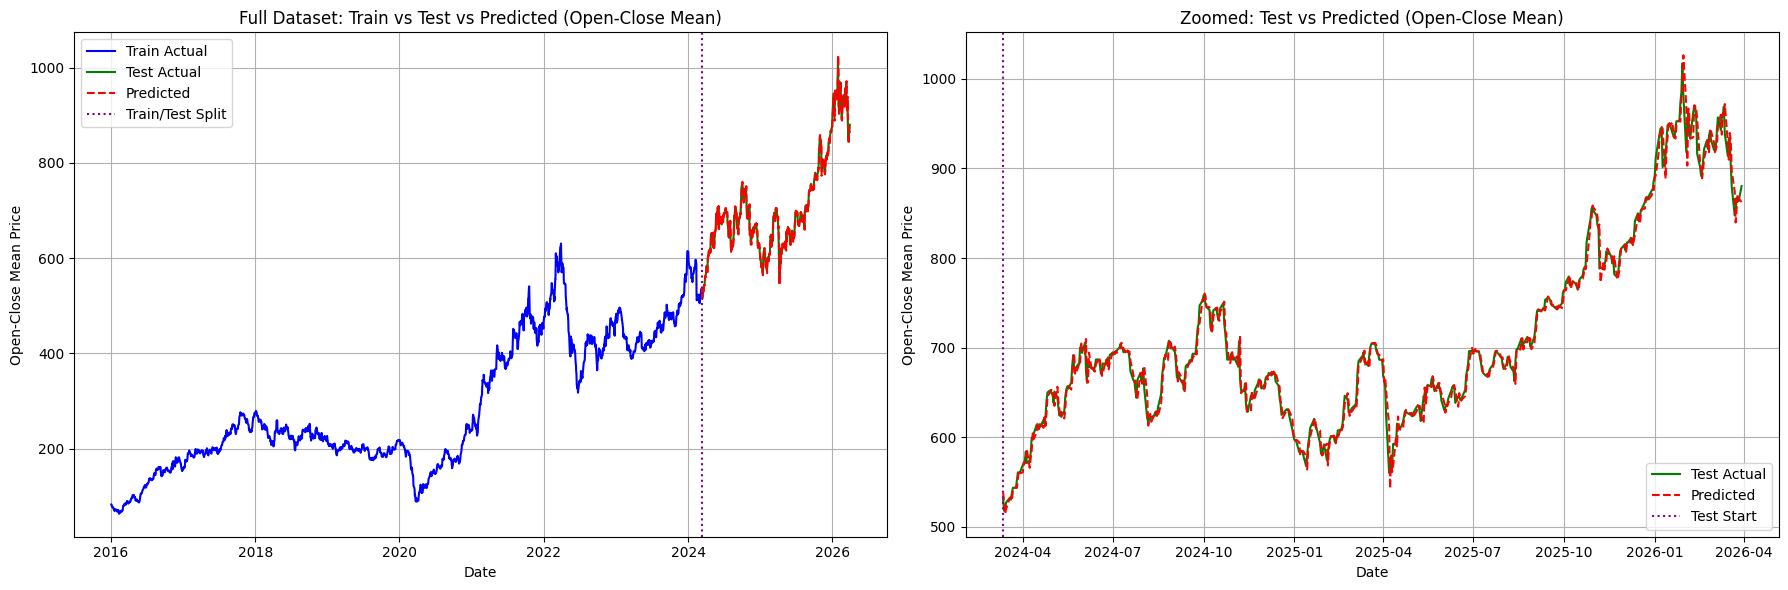


Final ARIMA Order: (0, 1, 1)
Final RMSE: 10.7304


In [ ]:
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left subplot: Full view
axes[0].plot(train.index, train, color='blue', label='Train Actual')
axes[0].plot(test.index, test, color='green', label='Test Actual')
axes[0].plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
axes[0].axvline(x=train.index[-1], color='purple', linestyle=':', label='Train/Test Split')
axes[0].set_title('Full Dataset: Train vs Test vs Predicted (Open-Close Mean)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Open-Close Mean Price')
axes[0].legend()
axes[0].grid(True)

# Right subplot: Zoomed test-only view
axes[1].plot(test.index, test, color='green', label='Test Actual')
axes[1].plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
axes[1].axvline(x=test.index[0], color='purple', linestyle=':', label='Test Start')
axes[1].set_title('Zoomed: Test vs Predicted (Open-Close Mean)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Open-Close Mean Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal ARIMA Order: {best_order}")
print(f"Final RMSE: {rmse:.4f}")